Mini-project: Heart disease classification evaluation

Features:
- chest pain (0/1)
- good blood circulation (0/1)
- blocked arteries (0/1)
- weight (continuous)

Target:
- heart disease = 0 / 1

We will compute:
- confusion matrix
- accuracy
- precision
- recall
- specificity
- F1 score
- ROC curve
- AUC
- k-fold cross validation

all without and with scikit-learn

In [100]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
from sklearn.model_selection import cross_val_score

Generate syntathic dataset:

In [108]:
np.random.seed(42)

m = 200

chest_pain = np.random.binomial(1, 0.4, m)
good_circ = np.random.binomial(1, 0.6, m)
blocked_art = np.random.binomial(1, 0.3, m)
weight = np.random.normal(180, 25, m)

# underlying logistic rule
logit = (
    1.2*chest_pain
    -1.0*good_circ
    +1.5*blocked_art
    +0.015*(weight-170)
)

prob = 1/(1+np.exp(-logit))

y = np.random.binomial(1, prob)

X = np.column_stack([chest_pain, good_circ, blocked_art, weight])

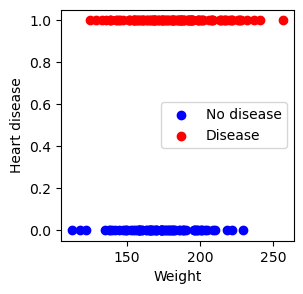

In [109]:
f, ax = plt.subplots(1,1,figsize=(3,3))

ax.scatter(weight[y==0], y[y==0], color="blue", label="No disease")
ax.scatter(weight[y==1], y[y==1], color="red", label="Disease")

ax.set_xlabel("Weight")
ax.set_ylabel("Heart disease")
ax.legend()

Standardize features:

In [110]:
X_mean = X.mean(axis=0)
X_std = X.std(axis=0) + 1e-8
Xs = (X - X_mean) / X_std

Train the model:

In [111]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def predict_proba(X, w, b): 
    z = X @ w + b
    return sigmoid(z)

def loss(X, y, w, b):
    p = predict_proba(X, w, b)
    eps = 1e-8 
    return - np.mean(y * np.log(p + eps) + (1 - y) * np.log(1 - p + eps))

def gradients(X, y, w, b):
    p = predict_proba(X, w, b)
    dw= X.T @ (p - y) / len(y)
    db = np.mean(p - y)
    return dw, db

def train(X, y, lr=0.01, n_steps=100):
    w = np.zeros(X.shape[1])
    b = 0.
    loss_history = []
    for step in range(n_steps):
        dw, db = gradients(X, y, w, b)
        w -= lr * dw
        b -= lr * db
        loss_history.append(loss(X, y, w, b))
    return w, b, loss_history

In [112]:
w, b, loss_history = train(Xs, y, lr=0.05, n_steps=500)

Text(0, 0.5, 'Loss')

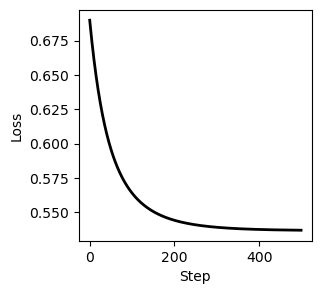

In [113]:
f, ax = plt.subplots(1,1, figsize=(3,3))
ax.plot(loss_history, lw=2, color='black')
ax.set_xlabel("Step")
ax.set_ylabel('Loss')

Decision boundary weight: 140.87619204260085


Text(0, 0.5, 'P(Heart Disease)')

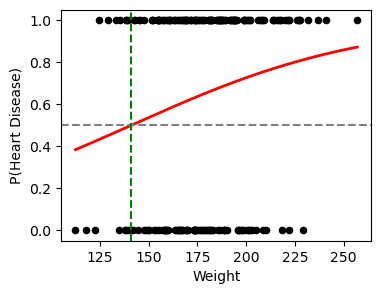

In [114]:
w_line = np.linspace(weight.min(), weight.max(), 200)
X_line = np.column_stack([
    np.full_like(w_line, chest_pain.mean()),
    np.full_like(w_line, good_circ.mean()),
    np.full_like(w_line, blocked_art.mean()),
    w_line
])
Xs_line = (X_line - X_mean) / X_std
p_line = predict_proba(Xs_line, w, b)

f, ax = plt.subplots(figsize=(4,3))

ax.scatter(weight, y, color="black", s=20)
ax.plot(w_line, p_line, color="red", lw=2)

ax.axhline(0.5, ls="--", color="gray")

boundary = w_line[np.argmin(np.abs(p_line-0.5))]
print("Decision boundary weight:", boundary)
ax.axvline(boundary, color="green", ls="--")

ax.set_xlabel("Weight")
ax.set_ylabel("P(Heart Disease)")

Confusion matrix:

In [115]:
def confusion_matrix(y_true, y_pred):
    TP = np.sum((y_true==1)&(y_pred==1))
    TN = np.sum((y_true==0)&(y_pred==0))
    FP = np.sum((y_true==0)&(y_pred==1))
    FN = np.sum((y_true==1)&(y_pred==0))
    return TP, TN, FP, FN

In [116]:
y_prob = predict_proba(Xs, w, b)
y_pred = (y_prob >= 0.5).astype(int)

TP, TN, FP, FN = confusion_matrix(y, y_pred)

print("TP:", TP)
print("TN:", TN)
print("FP:", FP)
print("FN:", FN)

TP: 102
TN: 44
FP: 33
FN: 21


Metrics:

In [119]:
def accuracy(TP,TN,FP,FN):
    return (TP+TN)/(TP+TN+FP+FN)

def precision(TP,FP):
    return TP/(TP+FP)

def recall(TP,FN):
    return TP/(TP+FN)

def specificity(TN,FP):
    return TN/(TN+FP)

def f1_score(p, r):
    return 2*p*r/(p+r)

In [121]:
print("Accuracy:", accuracy(TP,TN,FP,FN))
print("Precision:", precision(TP,FP))
print("Recall:", recall(TP,FN))
print("Specificity:", specificity(TN,FP))
print("F1:", f1_score(precision(TP,FP),recall(TP,FN)))

Accuracy: 0.73
Precision: 0.7555555555555555
Recall: 0.8292682926829268
Specificity: 0.5714285714285714
F1: 0.7906976744186047


ROC curve:

We need to consider many threshold to see which one is the best

In [81]:
thresholds = np.linspace(0,1,100)

tpr = []
fpr = []

for t in thresholds:

    y_pred = (prob >= t).astype(int)

    TP,TN,FP,FN = confusion_matrix(y, y_pred)

    tpr.append(recall(TP,FN))
    fpr.append(FP/(FP+TN))

Text(0, 0.5, 'True Positive Rate')

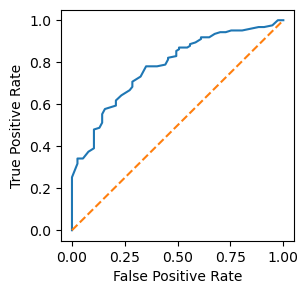

In [82]:
f, ax = plt.subplots(1,1,figsize=(3,3))
ax.plot(fpr, tpr)
ax.plot([0,1],[0,1],'--')
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")

We can do the same things with scikit-learn:

Train:

In [87]:
model = LogisticRegression()
model.fit(Xs,y)

y_pred = model.predict(Xs)
y_prob = model.predict_proba(Xs)[:,1]

Confusion matrix:

In [135]:
cm = confusion_matrix(y_true=y, y_pred=y_pred)
cm

array([[ 44,  33],
       [ 21, 102]])

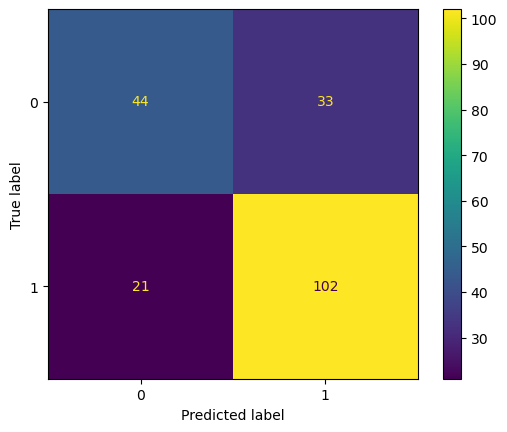

In [137]:
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

Metrics (a bit different because we did not make sure to use the same learning rate / number of epochs as in the manual training):

In [90]:
print("Accuracy:", accuracy_score(y,y_pred))
print("Precision:", precision_score(y,y_pred))
print("Recall:", recall_score(y,y_pred))
print("F1 score:", f1_score(y,y_pred))

Accuracy: 0.735
Precision: 0.7573529411764706
Recall: 0.8373983739837398
F1 score: 0.7953667953667953


- accuracy of 73.5%: meaning that roughly three quarters of the predictions are correct. While this indicates a reasonable overall performance, accuracy alone does not fully describe model behavior, especially in classification problems where different types of errors have different consequences.
- precision is approximately 0.76: meaning that when the model predicts heart disease, it is correct about 76% of the time. However, about 24% of positive predictions are false positives, indicating the model sometimes predicts disease when the patient is actually healthy.
- recall (sensitivity) is 0.83: meaning the model successfully detects 83% of patients with heart disease. This indicates the model is relatively good at identifying positive cases, missing only a small fraction of true positives.
- F1 score is approximately 0.79: indicating a good balance between precision and recall. This suggests the model performs reasonably well in detecting heart disease while limiting the number of false positive predictions.


ROC:

In [91]:
fpr,tpr,_ = roc_curve(y,y_prob)
roc_auc = auc(fpr,tpr)

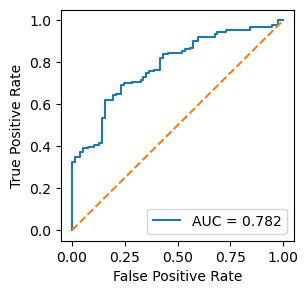

In [126]:
f, ax = plt.subplots(1,1,figsize=(3,3))
ax.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
ax.plot([0,1],[0,1],'--')
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend()

- ROC curve shows the relationship between the True Positive Rate (Recall) and the False Positive Rate across different classification thresholds
- dashed diagonal line represents the performance of a random classifier (AUC = 0.5)
- any model whose ROC curve lies above this line performs better than random guessing

Here, the ROC curve lies significantly above the diagonal, indicating that the model has a meaningful ability to distinguish between patients with and without heart disease

AUC of 0.782 means the model correctly ranks a positive example above a negative one about 78% of the time. The model demonstrates acceptable discriminative ability, meaning it can reasonably separate patients with heart disease from healthy individuals.


Cross validation (10-fold):

In [138]:
cv = cross_val_score(model,Xs,y,cv=10)
print(cv)
print('mean = ', cv.mean())

[0.65 0.7  0.75 0.65 0.75 0.9  0.8  0.6  0.6  0.7 ]
mean =  0.71


The mean cross-validation accuracy is approximately 0.71, which is close to the training accuracy. This indicates that the model generalizes reasonably well to unseen data and is not strongly overfitting the training set.

Overall, the logistic regression model performs reasonably well for this binary classification task. The model shows relatively high recall, meaning it successfully identifies most cases of heart disease. However, the lower specificity indicates that the model sometimes incorrectly predicts disease for healthy patients. This trade-off may be acceptable in medical screening contexts, where detecting as many positive cases as possible is often prioritized.